In [2]:
import pandas as pd
import mysql.connector

In [3]:
conn = mysql.connector.connect(
    host="localhost",
    user="root",
    password="a24967679",
    database="olist"
)

In [5]:
query = """
SELECT * 
from 
fact_analytic_base
"""
df = pd.read_sql(query, conn)
df.head()


/var/folders/vl/wskb2r0j55g_xcyvprs302bc0000gn/T/ipykernel_10252/3622206901.py:6: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, conn)


,order_id,order_item_id,customer_id,product_id,seller_id,order_purchase_timestamp,order_delivered_customer_date,order_estimated_delivery_date,delivery_delay_days,is_delivered_late,...,product_length_cm,product_height_cm,product_width_cm,review_score,review_creation_datetime,review_answer_datetime,review_comment_title,review_comment_message,has_review,has_comment
0,0009792311464db532ff765bf7b182ae,1,2a30c97668e81df7c17a8b14447aeeba,8cab8abac59158715e0d70a36c807415,530ec6109d11eaaf87999465c6afee01,2018-08-14 20:43:00,2018-08-22 12:02:00,2018-08-28,-6.0,0,...,40.0,20.0,30.0,5.0,2018-08-23,2018-08-23 16:11:00,,,1,1
1,000c3e6612759851cc3cbb4b83257986,1,3773bcf1a6fbd29233ea1c1b573c4f22,b50c950aba0dcead2c48032a690ce817,218d46b86c1881d022bce9c68a7d4b15,2017-08-12 10:08:00,2017-08-19 15:22:00,2017-09-01,-13.0,0,...,16.0,16.0,16.0,5.0,2017-08-20,2017-08-20 19:56:00,,Recebi td certinho antes do prazo!,1,1
2,00404fa7a687c8c44ca69d42695aae73,1,0c34c39c897304ff49eeade3059c4c60,53b36df67ebb7c41585e8d54d6772e08,7d13fca15225358621be4086e1eb0964,2018-05-07 22:38:00,2018-05-18 19:04:00,2018-05-24,-6.0,0,...,16.0,11.0,13.0,5.0,2018-05-19,2018-05-20 12:30:00,,,1,1
3,00418a49a685c6bb60633291c3fab17a,1,7d9edced80af5c9503cbf88a9e5f2a3e,5e21d5cab5d33e770d8150a4ee6117db,6560211a19b47992c3666cc44a7e94c0,2017-10-03 20:43:00,2017-10-05 19:53:00,2017-10-19,-14.0,0,...,16.0,2.0,11.0,1.0,2017-10-06,2017-10-14 03:57:00,,"O relógio, (presente do dia das crianças pra m...",1,1
4,004345d16a1ab2c21962992c721c8643,1,3b723b649feb48f3cfbb9c728efb3d7d,d0fb1e667e989933a80444f93da833c0,0be8ff43f22e456b4e0371b2245e4d01,2018-07-04 06:45:00,2018-07-11 17:26:00,2018-07-30,-19.0,0,...,18.0,19.0,16.0,5.0,2018-07-12,2018-07-12 20:59:00,Bom.,"Recebi tudo certinho, recomendo.",1,1


### 訂單數量、顧客數量、賣家數量、商品數量


In [9]:
order_count = df['order_id'].nunique()
customer_count = df['customer_unique_id'].nunique()
seller_count = df['seller_id'].nunique()
product_count = df['product_id'].nunique()


In [10]:
overview = pd.DataFrame({
    'Metric': ['Orders', 'Customers', 'Sellers', 'Products'],
    'Count': [order_count, customer_count, seller_count, product_count]
})

overview


,Metric,Count
0,Orders,96478
1,Customers,93358
2,Sellers,2970
3,Products,32216


<Axes: xlabel='Metric'>

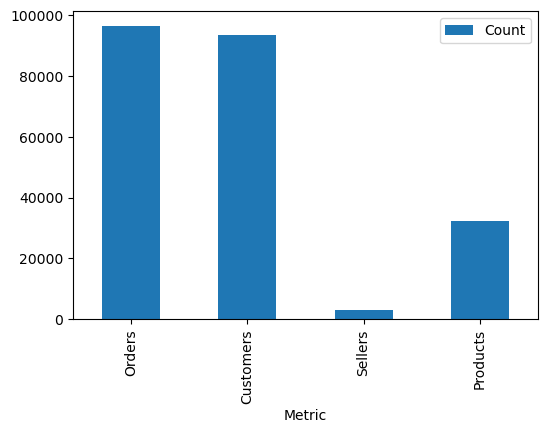

In [11]:
overview.plot(kind='bar', x='Metric', y='Count', figsize=(6,4))


# Time Series Overview（時間序列 EDA）

本章目標：了解銷售的時間分佈，找出旺季、淡季、趨勢與異常現象。

---

## 1. 分析維度

- By Day（每日）
- By Week（每週）
- By Month（每月）

---

## 2. 分析指標

- 訂單數（orders）
- 顧客數（unique customers）
- 賣家數（unique sellers）
- 商品銷售數（product count）
- 總營收（GMV：sum of price + freight）

---

## 3. 主要問題

1. 訂單量是否有明顯的旺季 / 淡季？
2. 每月 GMV 是否有穩定上升或下降？
3. 顧客與訂單數的成長是否同步？
4. 有無異常高峰（重大活動、大促）？
5. 工作日 vs 週末是否有模式？
6. 多個指標是否呈現同方向變化？


## 4. SQL 取數（從 fact_analytic_base）

In [12]:
query = """
SELECT
    order_purchase_timestamp,
    order_id,
    customer_unique_id,
    seller_id,
    product_id,
    price + freight_value AS gmv
FROM fact_analytic_base;
"""
df = pd.read_sql(query, conn)
df.head()

/var/folders/vl/wskb2r0j55g_xcyvprs302bc0000gn/T/ipykernel_10252/3939569041.py:11: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, conn)


,order_purchase_timestamp,order_id,customer_unique_id,seller_id,product_id,gmv
0,2018-08-14 20:43:00,0009792311464db532ff765bf7b182ae,4987996ddcd0ddb20740fdce7c2bfbb1,530ec6109d11eaaf87999465c6afee01,8cab8abac59158715e0d70a36c807415,127.55
1,2017-08-12 10:08:00,000c3e6612759851cc3cbb4b83257986,f5f088001070650f9e9a8cd773621f35,218d46b86c1881d022bce9c68a7d4b15,b50c950aba0dcead2c48032a690ce817,112.71
2,2018-05-07 22:38:00,00404fa7a687c8c44ca69d42695aae73,095ffc730d9d2da2f12a0bec18722aae,7d13fca15225358621be4086e1eb0964,53b36df67ebb7c41585e8d54d6772e08,99.90
3,2017-10-03 20:43:00,00418a49a685c6bb60633291c3fab17a,3b776563843bf7cb5adb4e65296aefae,6560211a19b47992c3666cc44a7e94c0,5e21d5cab5d33e770d8150a4ee6117db,56.78
4,2018-07-04 06:45:00,004345d16a1ab2c21962992c721c8643,8c07068e51d745035b296ebc1c8cd16a,0be8ff43f22e456b4e0371b2245e4d01,d0fb1e667e989933a80444f93da833c0,53.27


In [13]:
df['order_purchase_timestamp'] = pd.to_datetime(df['order_purchase_timestamp'])

df_daily = df.groupby(df['order_purchase_timestamp'].dt.date).agg({ # 根據購買日期(日)進行分組，聚合對應欄位
    'order_id': 'nunique', # 計算訂單編號唯一值數量
    'customer_unique_id': 'nunique', # 計算客戶編號唯一值數量
    'seller_id': 'nunique', # 計算賣家編號唯一值數量
    'product_id': 'nunique', # 計算商品編號唯一值數量
    'gmv': 'sum' # 計算分組GMV總額
}).reset_index()

df_daily.columns = ['date', 'orders', 'customers', 'sellers', 'products', 'gmv']


In [38]:
df_daily.head(20)

,date,orders,customers,sellers,products,gmv
0,2016-09-15,1,1,1,1,143.46
1,2016-10-03,7,7,6,7,559.53
2,2016-10-04,54,54,35,51,9821.42
3,2016-10-05,35,35,28,37,7209.50
4,2016-10-06,41,41,34,41,6798.90
5,2016-10-07,38,38,33,38,6824.46
6,2016-10-08,36,35,29,38,8475.93
7,2016-10-09,20,20,19,22,2904.19
8,2016-10-10,34,33,29,34,4077.55
9,2016-12-23,1,1,1,1,19.62


<Axes: title={'center': 'Daily Orders Trend'}, xlabel='date'>

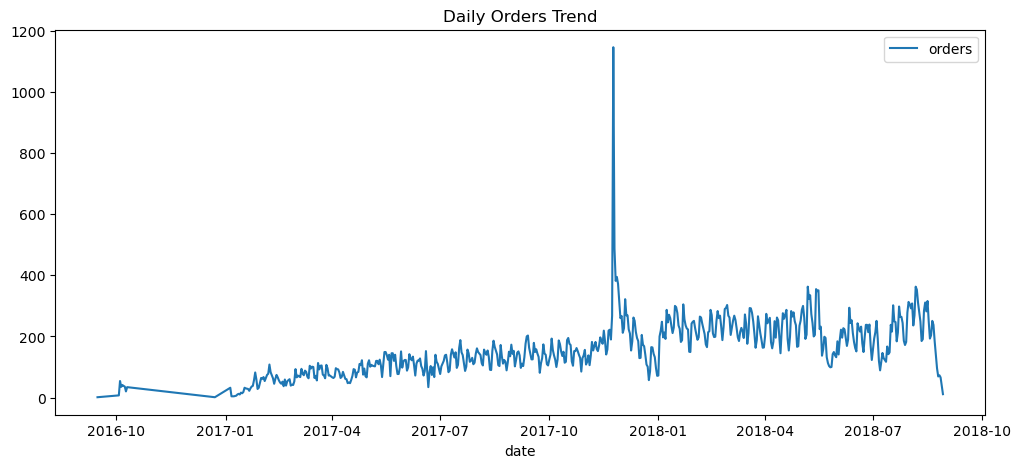

In [14]:
df_daily.plot(x='date', y='orders', figsize=(12,5), title='Daily Orders Trend')


<Axes: title={'center': 'Daily Customers Trend'}, xlabel='date'>

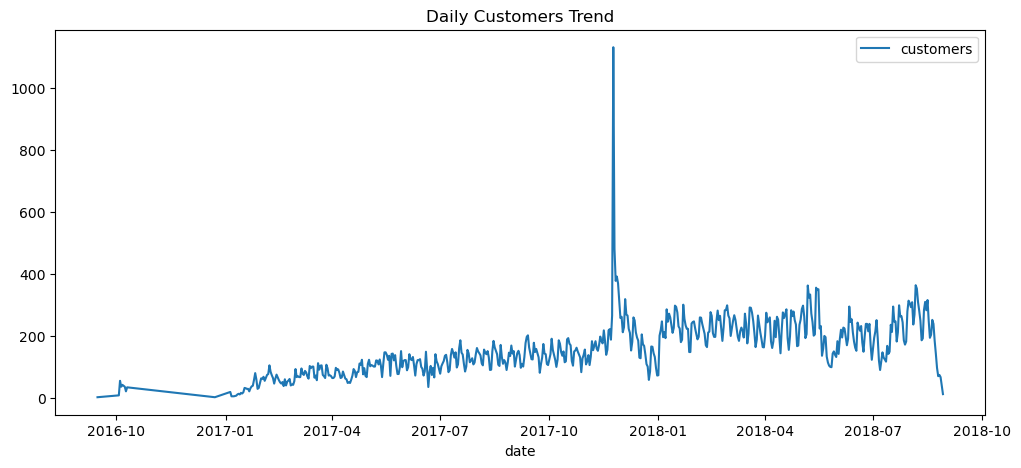

In [37]:
df_daily.plot(x='date', y='customers', figsize=(12,5), title='Daily Customers Trend')


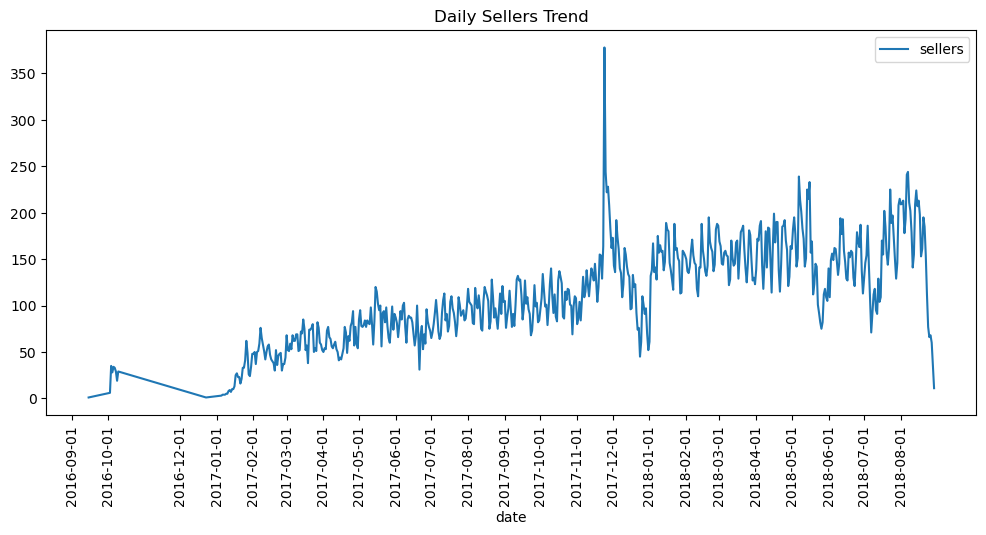

In [35]:
df_daily.plot(x='date', y='sellers', figsize=(12,5), title='Daily Sellers Trend')
plt.xticks(df_month['year_month'], rotation=90)
plt.show()

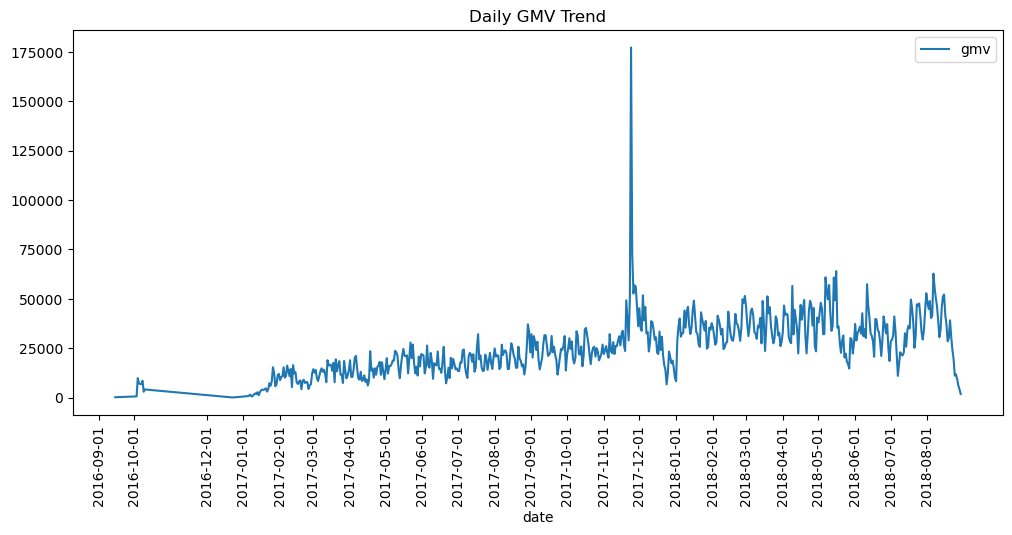

In [34]:
df_daily.plot(x='date', y='gmv', figsize=(12,5), title='Daily GMV Trend')
plt.xticks(df_month['year_month'], rotation=90)
plt.show()

year_month      object
order_count      int64
gmv            float64
dtype: object


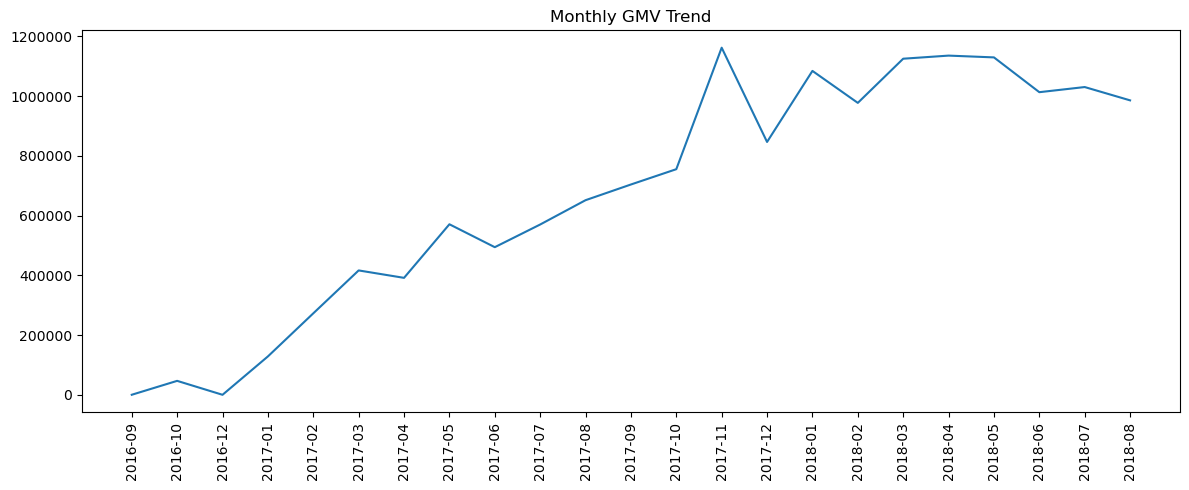

In [32]:
# 1. 建立 year_month（Period）
df['year_month'] = df['order_purchase_timestamp'].dt.to_period('M')

# 2. groupby 後直接命名好欄位
df_month = df.groupby('year_month', as_index=False).agg(
    order_count=('order_id', 'nunique'),
    gmv=('gmv', 'sum')
)

# 3. 把 Period 轉成字串（這一步是關鍵，避免 Period 進 matplotlib）
df_month['year_month'] = df_month['year_month'].astype(str)

# 4. 確認一下型別（debug 用，可看一眼）
print(df_month.dtypes)
# year_month     object
# order_count     int64
# gmv           float64 / int64

# 5. 畫圖
plt.figure(figsize=(12,5))
plt.plot(df_month['year_month'], df_month['gmv'])

plt.title('Monthly GMV Trend')
plt.xticks(df_month['year_month'], rotation=90)
plt.ticklabel_format(style='plain', axis='y')
plt.tight_layout()
plt.show()


In [26]:
df_month

,year_month,order_id,gmv
0,2016-09,1,143.46
1,2016-10,265,46671.48
2,2016-12,1,19.62
3,2017-01,750,128454.10
4,2017-02,1653,272657.26
5,2017-03,2546,416327.30
6,2017-04,2303,391484.45
7,2017-05,3546,570837.90
8,2017-06,3135,494147.47
9,2017-07,3872,570027.48


In [39]:
df.isna().sum()

order_purchase_timestamp    0
order_id                    0
customer_unique_id          0
seller_id                   0
product_id                  0
gmv                         0
year_month                  0
dtype: int64